<a href="https://colab.research.google.com/github/heisenberg304/Housing-Prices-prediction/blob/develop/analisis%202.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
%%writefile data_housing.py
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

#cargar datos
data_original = pd.read_csv("/content/drive/MyDrive/data_csv/House_Prices_train.csv")


Writing data_housing.py


In [47]:
from data_housing import data_original  #1460 casos
data = data_original.copy()

#revisar si hay valores faltantes con:
missing = data.isnull().sum().sort_values()
missing = missing[missing > 0]


#manejo de nan de basement
nan_bsmt = ['BsmtFinType1', 'BsmtQual', 'BsmtCond', 'BsmtFinType2', 'BsmtExposure']
data['BsmtFinType2'].value_counts()
data.loc[
    data["BsmtFinType2"].isna(),
    nan_bsmt
]
data.loc[948, 'BsmtExposure'] = 'No'
data.loc[332, 'BsmtFinType2'] = 'Unf'
data[nan_bsmt] = data[nan_bsmt].fillna('NoBsmt')


#manejo de nan de garage
nan_garage = ['GarageQual', 'GarageFinish', 'GarageType', 'GarageCond']
data.loc[
    data["GarageQual"].isna(),
    ['GarageQual', 'GarageYrBlt', 'GarageFinish', 'GarageType', 'GarageCond']
]
data[nan_garage] = data[nan_garage].fillna('NoGarage')
data['GarageYrBlt'] = data['GarageYrBlt'].fillna(0)


,GarageYrBlt
0,2003.0
1,1976.0
2,2001.0
3,1998.0
4,2000.0
5,1993.0
6,2004.0
7,1973.0
8,1931.0
9,1939.0


#Analizar cada caso de variable con NaNs

Estoy rellenando para los modelos mas basicos que no soportan NaNs, despues probare los modelos que soportan NaNs con el dataset rellenado y luego con NaNs para ver si hay una diferencia en el rendimiento

---
##Valores con muchos NaNs
* MasVnrType	(872)
* Fence	(1179)
* Alley	(1369)
* MiscFeature	(1406)
* PoolQC	(1453)
* FireplaceQu	(690)

---

##Valores con poco NaNs
* Electrical	(1): rellenado con SBrkr clase dominante
* MasVnrArea	(8): rellenado con 0, ya que la mayoria de personas no tienen area de revestimiento exterior

---
###Manejo de NaN en las variables faltantes relacionadas con basement

Todas estos valores faltantes seran rellenados con esta nueva categorias 'NoBsmt', habran 2 casos especiales explicados a continuacion.
* BsmtFinType1	(37): Área terminada del sótano principal.
* BsmtQual	(37): Calidad del sótano.
* BsmtCond	(37): Condición del sótano.
* BsmtFinType2	(38): La observación 332 presenta un valor faltante en BsmtFinType2.
Dado que la vivienda sí posee sótano terminado (BsmtFinSF2 > 0),
el valor faltante no representa ausencia de sótano.

Al tratarse de un único registro y no existir información suficiente
para inferir la categoría exacta, se imputó utilizando la categoría
más frecuente (Unf).
* BsmtExposure	(38): Porque la vivienda posee sótano
(TotalBsmtSF = 936).
Por tanto el NaN no representa ausencia de sótano.

Analicé la distribución de BsmtExposure y observé que la categoría "No" era ampliamente dominante.
Dado que se trata de un único registro anómalo, imputar "No" preserva la consistencia del dataset sin introducir una categoría incorrecta.

---
###Manejo de NaN en las variables faltantes relacionadas con Garage
* GarageQual	(81)
* GarageYrBlt	(81)
* GarageFinish	(81)
* GarageType	(81)
* GarageCond	(81)

* LotFrontage	(259)

##Features a eliminar
* Id: No aporta informacion relevante
*


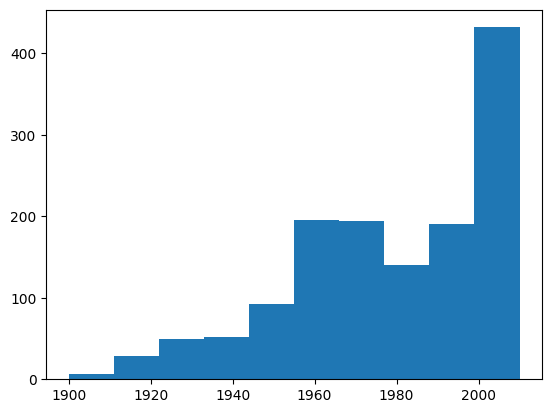

np.float64(1978.5061638868744)

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
data = pd.read_csv("/content/drive/MyDrive/data_csv/House_Prices_train.csv")

plt.hist(data["GarageYrBlt"])
plt.show()

data["GarageYrBlt"].mean()